# Decision Trees and Ensemble Methods

## Introduction

**Dataset**: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

Cardiovascular diseases (CVDs) are the leading cause of death globally, responsible for an estimated 17.9 million lives each year. Heart failure is one of the most common outcomes of CVDs, and early detection is critical.

In this notebook, we will build a machine learning model to predict whether a patient has heart disease based on the given clinical measurements and explore the use of different decision tree classifiers.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Checking for Duplicates and Missing Values

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

No duplicates and no missing values. So we do not need to worry about dropping rows or filling in gaps. We can move straight to exploring the data.

## Exploratory Data Analysis

Our target variable is `HeartDisease`. Let us check the distribution of this variable.

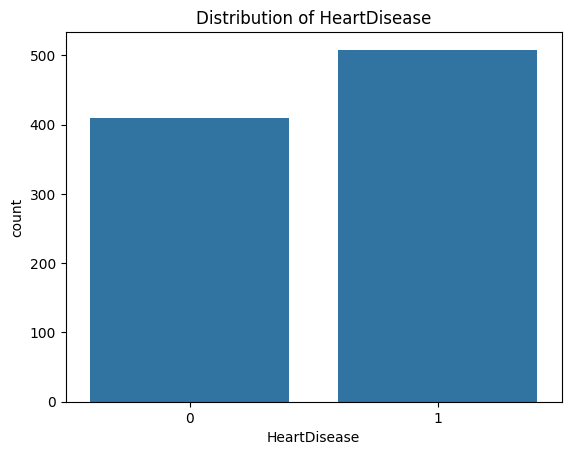

In [5]:
sns.countplot(data=df, x="HeartDisease")
plt.title("Distribution of HeartDisease")
plt.show()

The two classes are fairly balanced. Roughly 45% do not have any heart disease and the others (approximately 55%) do.

Let us look at the numerical features next, split by `HeartDisease`, to see if any of them separate the two classes well.

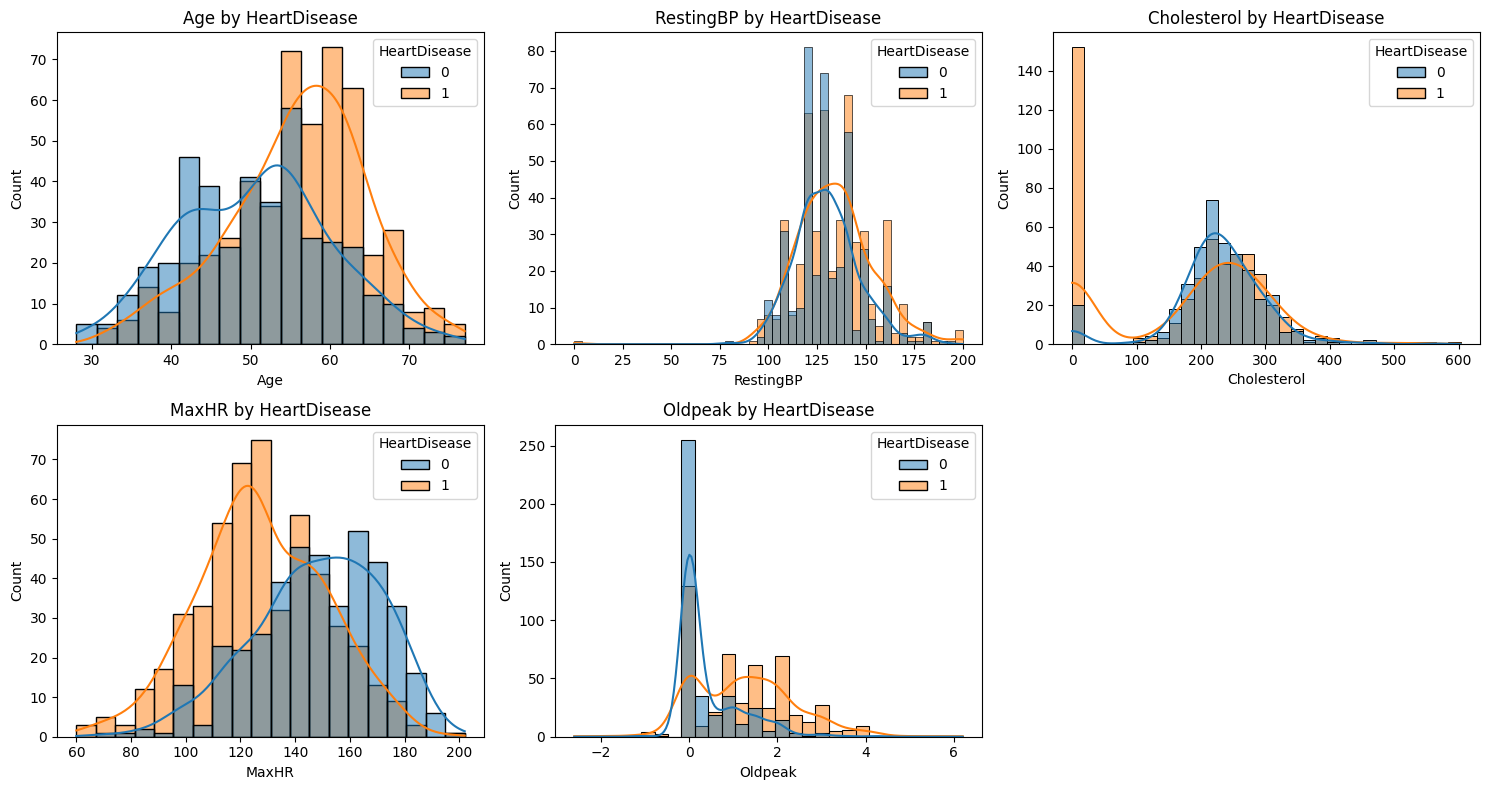

In [6]:
num_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue="HeartDisease", kde=True, ax=axes[i])
    axes[i].set_title(f"{col} by HeartDisease")

fig.delaxes(axes[-1]) # Remove the last empty subplot
plt.tight_layout()
plt.show()

A few things stand out here. Patients with heart disease tend to be a bit older on average. `MaxHR` (maximum heart rate achieved) tends to be lower in patients with heart disease, and `Oldpeak` (ST depression induced by exercise) tends to be higher. `Cholesterol` also has a strange spike at 0 (which is almost impossible for living persons), which is likely a missing value that was encoded as 0 rather than a real reading. We will keep this in mind, though decision trees can usually handle this kind of noise reasonably well.

Let us also check the categorical features against the target.

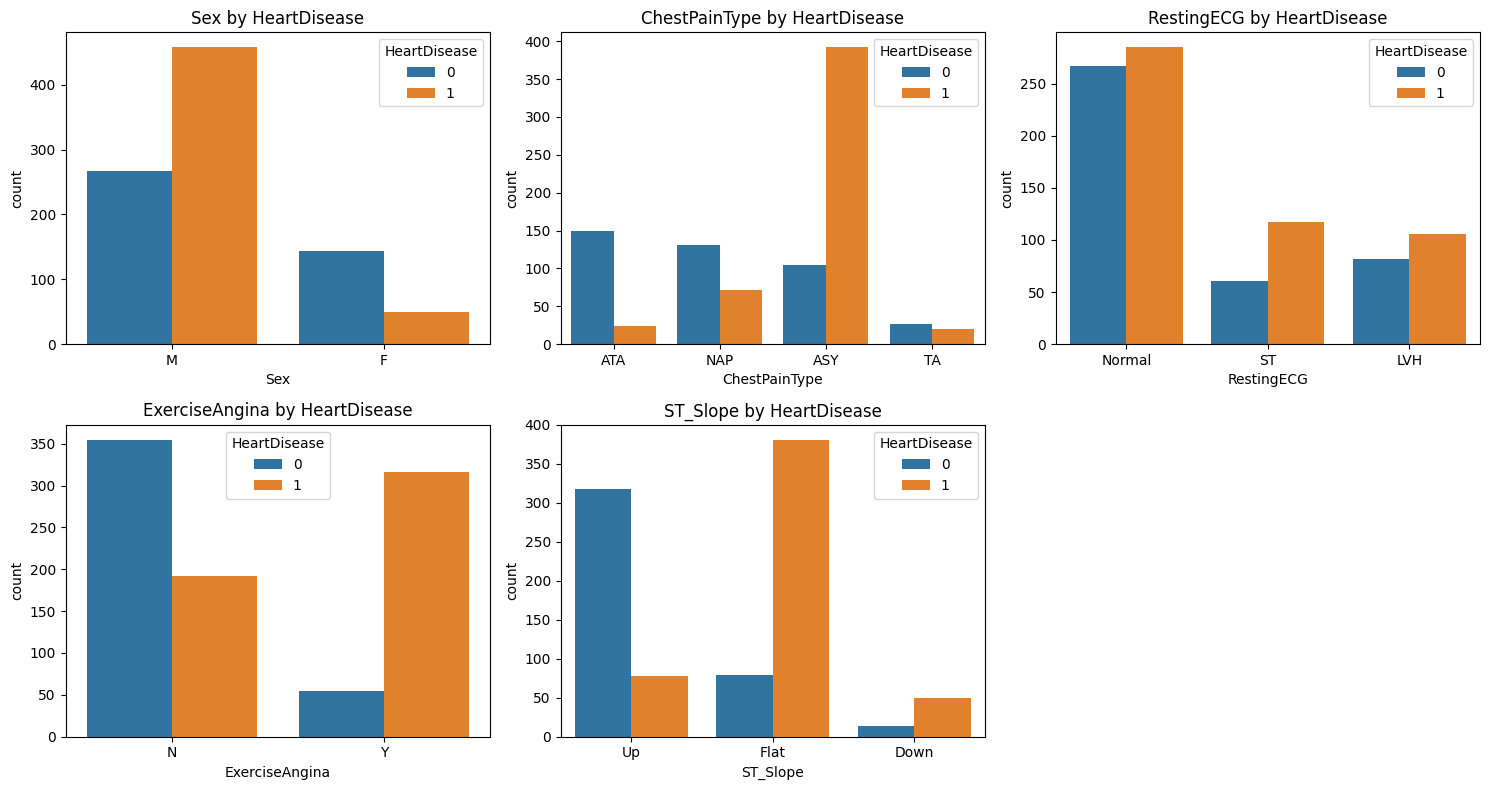

In [7]:
cat_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue="HeartDisease", ax=axes[i])
    axes[i].set_title(f"{col} by HeartDisease")

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

Some clear patterns here too. `ChestPainType` *ASY* (asymptomatic) is strongly linked with heart disease. This might seem counterintuitive, but "asymptomatic" here means no chest pain despite having the disease, which is exactly why early detection matters. `ExerciseAngina` *Y* (exercise induced angina) is also strongly linked with heart disease, and `ST_Slope` *Flat* and *Down* are linked with heart disease, while *Up* is linked with no heart disease.

These categorical features look like they will be useful predictors, which is a good sign heading into modelling.

Now let us check how the numerical features relate to each other and to the target using a correlation heatmap.

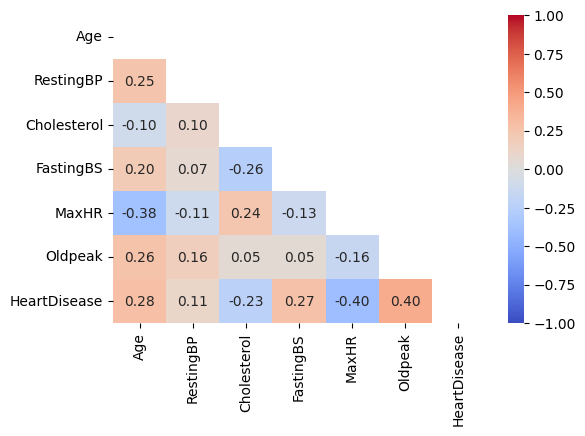

In [8]:
correlations = df.corr(numeric_only=True)

mask = np.zeros_like(correlations, dtype=bool)
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(6, 4))
sns.heatmap(correlations, annot=True, fmt=".2f", mask=mask, vmin=-1, vmax=1, cmap="coolwarm")
plt.show()

`Oldpeak` and `MaxHR` show the strongest correlation with `HeartDisease` among the numerical features. None of the features are extremely correlated with each other, so we do not have any obvious multicollinearity issue, though this is not a problem anyway.

Unlike in Logistic and Linear Regression, **multicollinearity between features is not a problem for decision trees**. This is because a tree picks one feature at a time to split on, based on which split best separates the classes. It does not estimate coefficients across all features at once the way a linear model does, so two highly correlated features do not distort the model.

## Encoding Categorical Variables

`Sex` and `ExerciseAngina` are binary categories, so we can map these directly to 0 and 1. There is no ordering issue since there are only two options.

`ChestPainType`, `RestingECG`, and `ST_Slope` are nominal categories with more than two values. These do not have a natural numeric order. Instead, we use one-hot encoding.

In [9]:
df["Sex"] = df["Sex"].map({"M": 1, "F": 0})
df["ExerciseAngina"] = df["ExerciseAngina"].map({"Y": 1, "N": 0})

df = pd.get_dummies(df, columns=["ChestPainType", "RestingECG", "ST_Slope"])

df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,False,True,False,False,False,True,False,False,False,True
1,49,0,160,180,0,156,0,1.0,1,False,False,True,False,False,True,False,False,True,False
2,37,1,130,283,0,98,0,0.0,0,False,True,False,False,False,False,True,False,False,True
3,48,0,138,214,0,108,1,1.5,1,True,False,False,False,False,True,False,False,True,False
4,54,1,150,195,0,122,0,0.0,0,False,False,True,False,False,True,False,False,False,True


## Getting our Features and Target

In [10]:
X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

## Splitting into Train and Test Sets

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

There is no need to scale numerical features because decision trees split on threshold values for one feature at a time, for example "is `Oldpeak` greater than 1.5?". The scale of the feature does not change where that split lands relative to the other data points. Only the labelled value on the axis changes.

This is different from Logistic and Linear Regression, where predictions come from a weighted sum of all features. In those models, features on a larger scale (like `Cholesterol` in the hundreds) can dominate features on a smaller scale (like `Oldpeak` between 0 and 6) unless everything is scaled to a comparable range first.

Decision trees do not have this issue, so we can skip scaling entirely.

Now, we can train and evaluate our models.

## Training and Evaluating a Decision Tree

In [12]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [13]:
from sklearn.metrics import accuracy_score, classification_report

In [14]:
y_pred = dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8098
              precision    recall  f1-score   support

           0       0.74      0.84      0.79        77
           1       0.88      0.79      0.83       107

    accuracy                           0.81       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.82      0.81      0.81       184



Our decision tree has an accuracy of 80.98%.

However, a single decision tree by itself is weak. It is better we use ensembling. Both bagging and boosting usually give a more accurate and more stable model than any single tree on its own.

## Ensemble Models

### RandomForest

Random Forest builds many decision trees using bagging and averages their predictions (for classification, it takes a majority vote). At each split, only a random subset of features is considered, which makes the trees more different from each other.

It is a solid choice when you want a strong, reasonably fast model.

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [16]:
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8804
              precision    recall  f1-score   support

           0       0.84      0.88      0.86        77
           1       0.91      0.88      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



### XGBoost

XGBoost (Extreme Gradient Boosting) is a popular boosting method. It builds trees one at a time, where each new tree is trained to correct the errors of the trees before it, and adds regularization on top of standard gradient boosting to help control overfitting.

In [17]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)

xgb.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [18]:
y_pred = xgb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8587
              precision    recall  f1-score   support

           0       0.80      0.88      0.84        77
           1       0.91      0.84      0.87       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



### LightGBM

LightGBM is another gradient boosting method, built with speed and memory efficiency in mind. The main difference from XGBoost is how the trees grow. XGBoost grows trees level by level, while LightGBM grows trees leaf by leaf, always splitting whichever leaf will reduce the error the most. This tends to produce faster trees, though it can also overfit more easily on small datasets if not tuned carefully.

It is popular when working with large datasets or when training speed matters.

In [19]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(random_state=42, verbose=-1)

lgbm.fit(X_train, y_train)

,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


In [20]:
y_pred = lgbm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8478
              precision    recall  f1-score   support

           0       0.80      0.86      0.82        77
           1       0.89      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.84      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



### CatBoost

CatBoost (Category Boosting) is a gradient boosting method designed specifically to handle categorical features well without needing to manually one-hot encode them first. It uses a technique called ordered boosting, which reduces a subtle form of overfitting called prediction shift that can affect other boosting methods.

Since we already one-hot encoded our categorical features earlier, we lose a bit of CatBoost's main advantage here, but it is still a strong general purpose booster. It is especially handy on real world tabular datasets that are heavy on categorical features.

In [21]:
from catboost import CatBoostClassifier

cb = CatBoostClassifier(random_state=42, verbose=0)

cb.fit(X_train, y_train)

CatBoostClassifier(random_state=42, verbose=0)

In [22]:
y_pred = cb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8913
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        77
           1       0.91      0.90      0.91       107

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



### Results

As expected, our ensemble models performed better than a single decision tree.

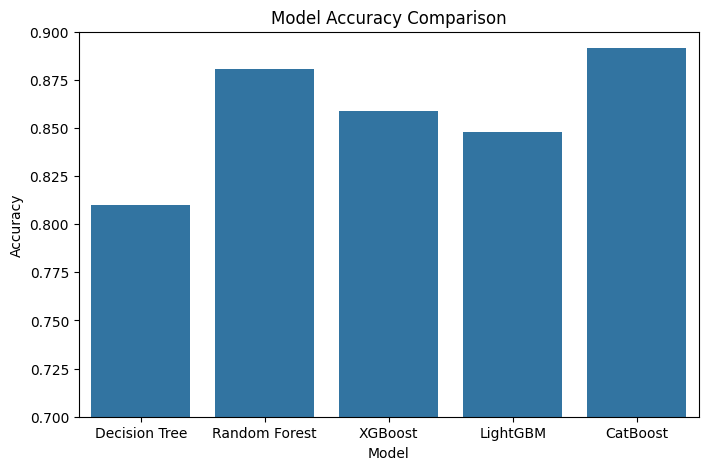

In [23]:
results = {
    "Decision Tree": accuracy_score(y_test, dt.predict(X_test)),
    "Random Forest": accuracy_score(y_test, rf.predict(X_test)),
    "XGBoost": accuracy_score(y_test, xgb.predict(X_test)),
    "LightGBM": accuracy_score(y_test, lgbm.predict(X_test)),
    "CatBoost": accuracy_score(y_test, cb.predict(X_test)),
}

results_df = pd.DataFrame(results.items(), columns=["Model", "Accuracy"])

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.ylim(0.7, 0.9)
plt.title("Model Accuracy Comparison")
plt.show()

## Voting

Voting is an ensemble method that combines multiple individual models to make a final prediction, rather than relying on any single model alone. How it combines them depends on the type of problem.

For **regression**, voting predicts the average of the individual predictions.

For **classification**, there are two approaches:

- **Hard Voting**: Selects the class that receives the majority of votes across the individual classifiers.
- **Soft Voting**: Sums the predicted probabilities for each class across all classifiers, and selects the class with the highest total.

By default, each individual model contributes equally to the final prediction, though it is possible to assign different weights so that some models count more than others.

In [24]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("xgb", xgb),
        ("lgbm", lgbm),
        ("cb", cb),
    ],
    voting="soft", weights=[2, 1, 1, 3] # CatBoost has the highest weight due to its superior performance
)

voting_clf.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('xgb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[2, 1, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[RandomForestC...ndom_state=42), XGBClassifier...ree=None, ...), LGBMClassifie...2, verbose=-1), CatBoostClass...42, verbose=0)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U17](18,)","['Age','Sex','RestingBP',...,'ST_Slope_Down','ST_Slope_Flat','ST_Slope_Up']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [25]:
y_pred = voting_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8967
              precision    recall  f1-score   support

           0       0.88      0.87      0.88        77
           1       0.91      0.92      0.91       107

    accuracy                           0.90       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.90      0.90      0.90       184

